In [65]:
import os
import pandas as pd
from typing import List, Tuple
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import json
from torch.utils.data import DataLoader
from model.lstm import LSTMMdel
import torch
import torch.nn as nn

font = {'size': 16}

matplotlib.rc('font', **font)

In [66]:
DATASET_PATH = "../../dataset"
INDEX_FIELD = "timestamp"
DATA_FIELD = "num_request"
CPD_CANDIDATE_ROOT = "../../change_point_detection/offline_detection/cpd_candidate"
N_LOOKBACK = 4
N_PREDICT = 2

DEVICE="cuda" if torch.cuda.is_available else "cpu"

In [67]:
def get_data_file_list(dataset_path: str) -> List[str]:
    return os.listdir(dataset_path)

In [68]:
def read_dataset(csv_path: str,index_field:str,data_field:str) -> Tuple[np.ndarray, np.ndarray]:
    df = pd.read_csv(csv_path)
    return df[index_field].to_numpy(), df[data_field].to_numpy()

In [69]:
def read_candidate_cpds(path: str) -> List[int]:
    candidate_cpds = None
    with open(path, "r") as f:
        candidate_cpds = json.load(f)
    return candidate_cpds

In [70]:
def build_dataset(np_data: np.ndarray, candidate_cpds: List[int]):
    x = []
    y = []
    candidate_cpds = np.array(candidate_cpds, dtype=np.int32)
    np_data = np_data/20000.0
    for idx in range(len(np_data)-N_LOOKBACK-N_PREDICT+2):
        x.append(np_data[idx:idx+N_LOOKBACK+N_PREDICT-1].reshape((-1, 1)))
        is_less = candidate_cpds < idx+N_LOOKBACK+N_PREDICT
        future_candidate_idx = np.sum(is_less)
        if future_candidate_idx < len(candidate_cpds):
            nearest_cpd = candidate_cpds[future_candidate_idx]
            if nearest_cpd > idx + N_LOOKBACK+N_PREDICT+N_PREDICT:
                y.append(0)
            elif nearest_cpd >= idx + N_LOOKBACK+N_PREDICT:
                y.append(1)
            # else:
            #     y.append(2)
        else:
            y.append(0)
    # x = np.array(x)
    # y = np.array(y)
    return x, y

In [71]:
workload_to_skip_list = ["workload_1998-06-13", "workload_1998-06-14", "workload_1998-06-20", "workload_1998-06-21", "workload_1998-06-27", "workload_1998-06-28","workload_1998-07-04"]

read workload_1998-06-10.csv
read workload_1998-06-11.csv
read workload_1998-06-12.csv
read workload_1998-06-15.csv
read workload_1998-06-16.csv
read workload_1998-06-17.csv
read workload_1998-06-18.csv
read workload_1998-06-19.csv
read workload_1998-06-22.csv
read workload_1998-06-23.csv
read workload_1998-06-24.csv
read workload_1998-06-25.csv
read workload_1998-06-26.csv
read workload_1998-06-29.csv
read workload_1998-06-30.csv
read workload_1998-07-03.csv
read workload_1998-07-07.csv
read workload_1998-07-08.csv


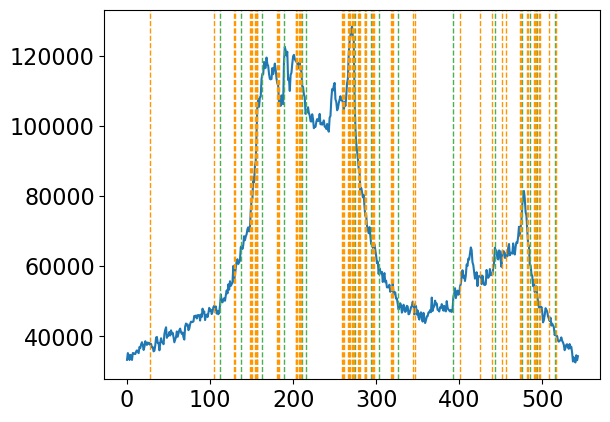

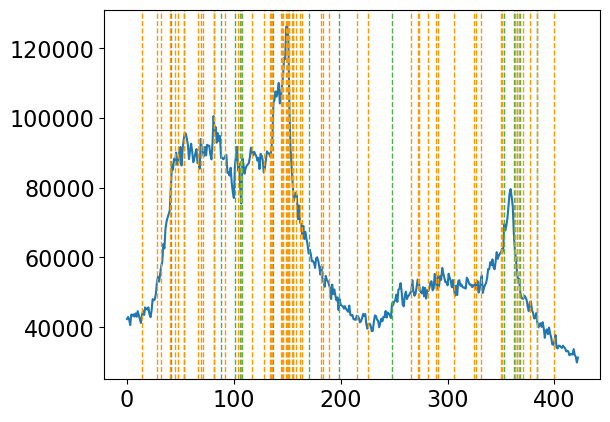

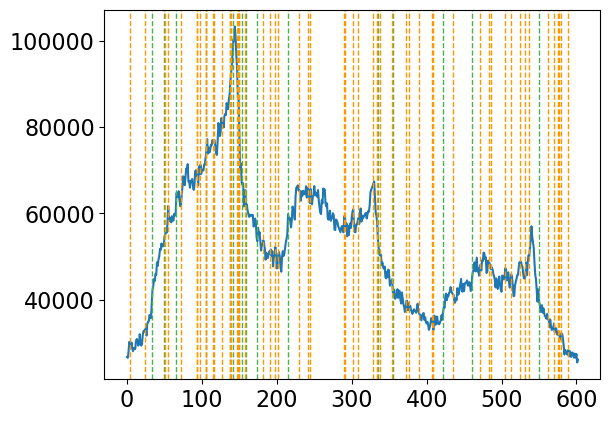

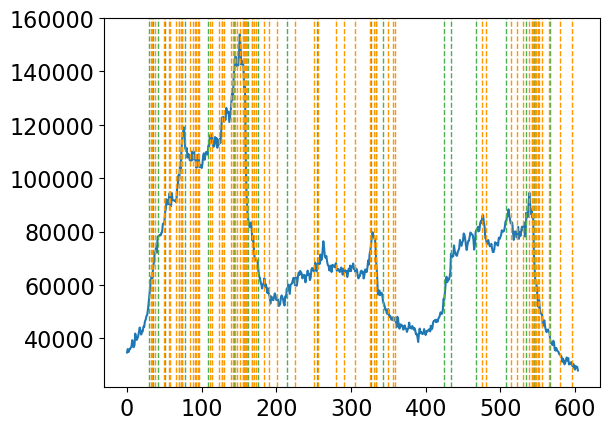

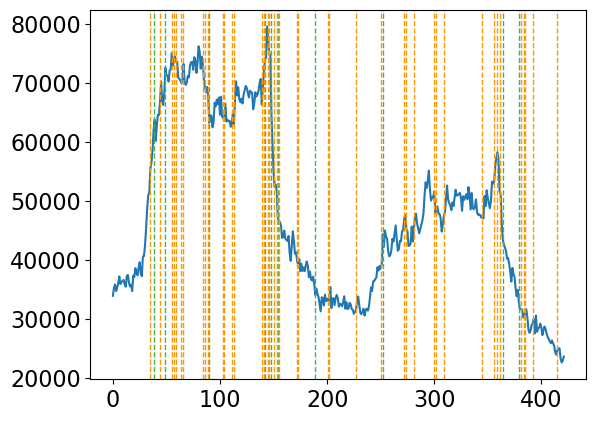

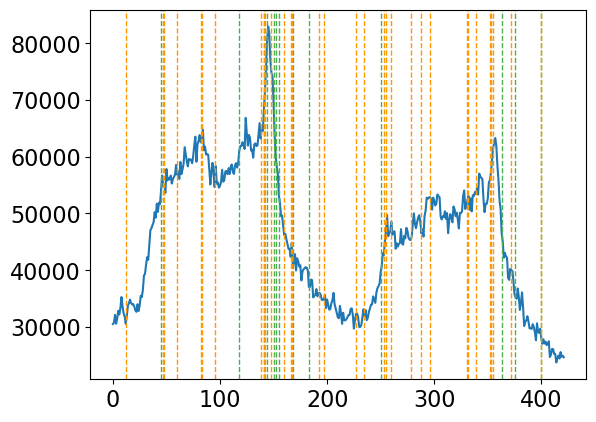

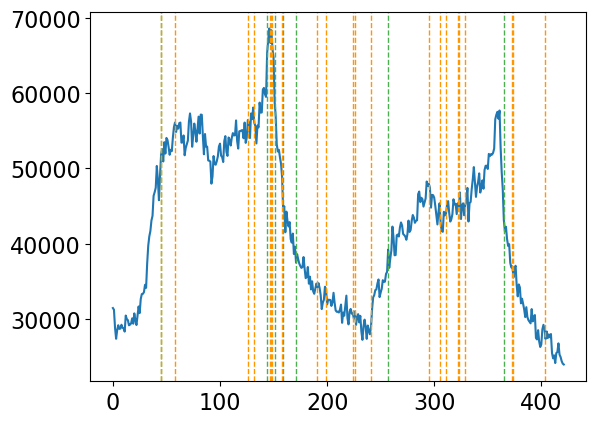

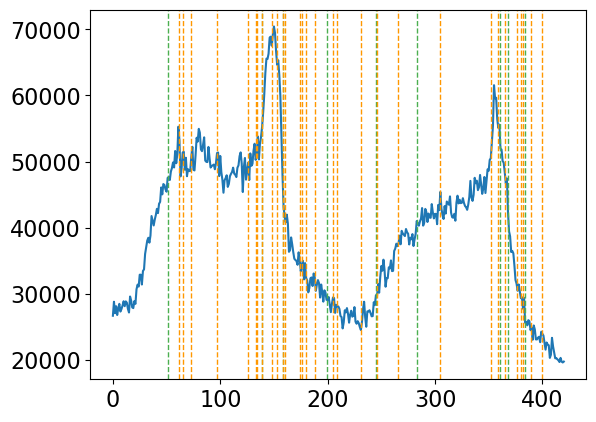

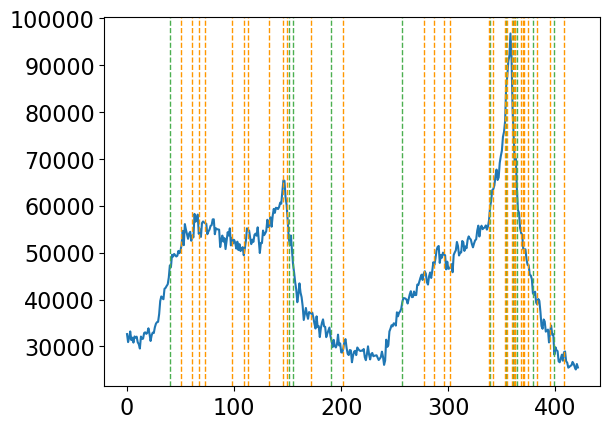

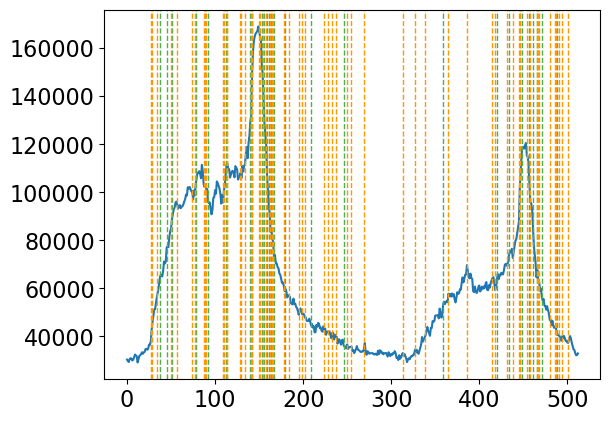

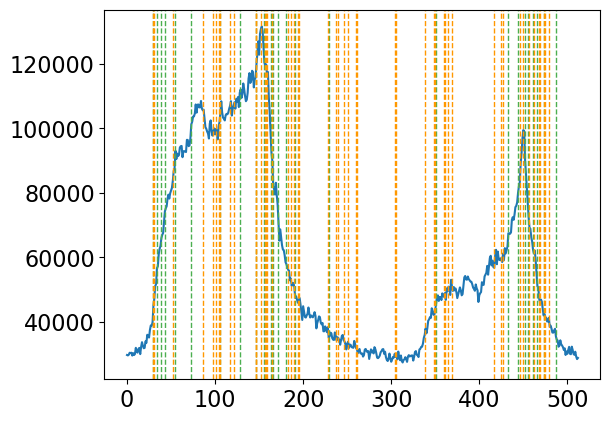

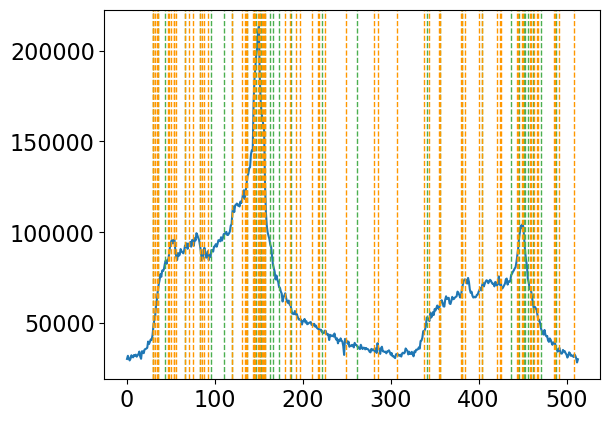

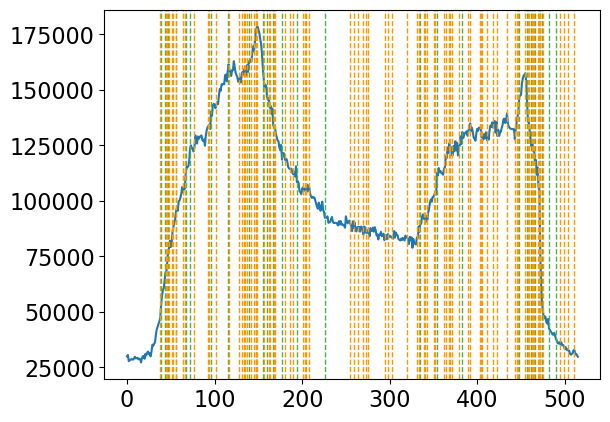

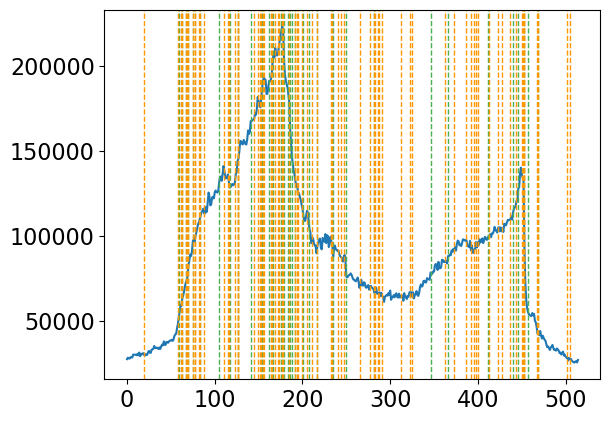

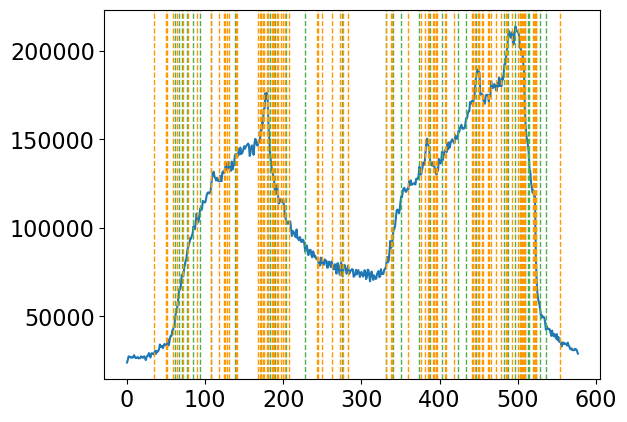

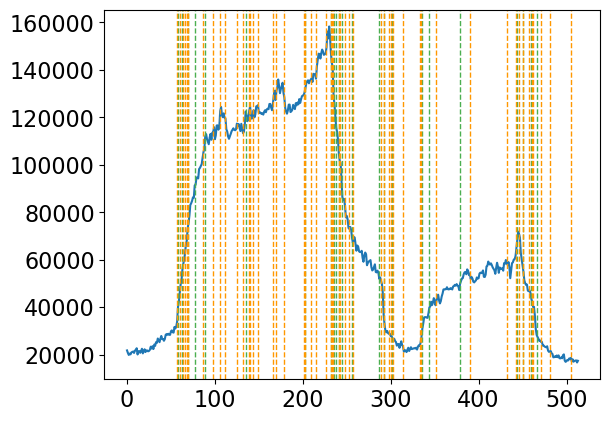

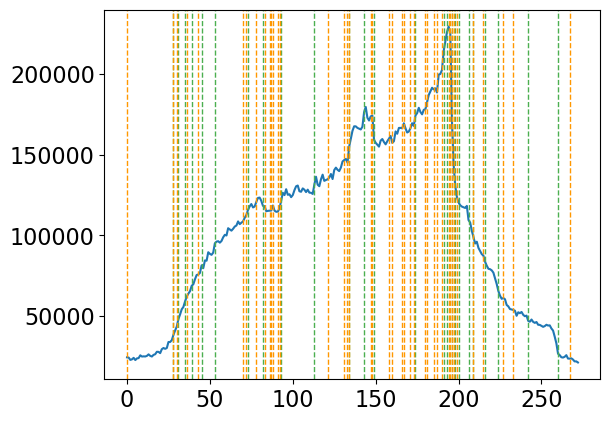

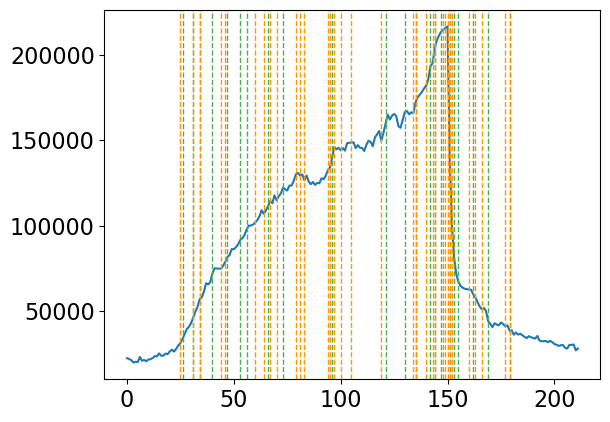

In [72]:
import json
data_file_list = get_data_file_list(DATASET_PATH)
model = LSTMMdel(1, 64, 2, 1).to(DEVICE)
model.load_state_dict(torch.load("state_dict/lstm.pth"))
for file_name in data_file_list:
    workload_name = file_name.split(".")[0]
    if workload_name in workload_to_skip_list:
        continue
    print("read %s" % (file_name))
    np_index, np_data = read_dataset(os.path.join(DATASET_PATH, file_name), INDEX_FIELD, DATA_FIELD)
    np_data_diff = np.diff(np_data).reshape((-1,1))
    candidate_cpds = read_candidate_cpds(os.path.join(CPD_CANDIDATE_ROOT, workload_name+".json"))
    workload_diff, _ = build_dataset(np_data_diff, candidate_cpds)
    
    y_pd = []
    for x in workload_diff:
        x = torch.tensor(x, dtype=torch.float32).to(DEVICE)
        y_pd.append(torch.argmax(model(x)).detach().cpu().item())
    cpds_pd = np.where(np.array(y_pd) == 1)[0]
    fig, ax = plt.subplots()
    ax.plot(np_data)
    for cp in candidate_cpds:
        ax.axvline(x=cp, color="#4CAF50", linestyle='--', linewidth=1)
    for cp in cpds_pd:
        ax.axvline(x=cp, color="#FF9800", linestyle='--', linewidth=1)